## NLP Final
### Part 2: Topic Detection - NMF (Title)
### Aren Mizuno
### March 12, 2026

In [1]:
# Imports
import matplotlib.pyplot as plt
import re
import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from google.colab import drive

In [2]:
# Cuda
torch.cuda.is_available()

True

In [3]:
# Mount drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Load the cleaned dataset
data_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/news_final_project_cleaned.parquet"
df = pd.read_parquet(data_path, engine="pyarrow")
df.head(2)

,url,date,title,text
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,This AI video of gymnastics might be the freak...


In [5]:
# Check shape
df.shape

(136233, 4)

In [7]:
# Text cleaning helpers
TOPIC_JUNK_PHRASES = [
    "open menu", "menu", "search", "login", "log in", "sign up", "sign in",
    "subscribe", "privacy policy", "terms of service", "terms and conditions",
    "contact us", "contact support", "newsletter", "skip to content",
    "follow us", "read the rules", "mobile app", "read more", "click here",
    "all rights reserved", "advertisement", "sponsored content",
    "yahoo finance", "reuters", "associated press", "ap news",
]

TOPIC_JUNK_WORDS = {
    "home", "world", "business", "finance", "sports", "weather",
    "entertainment", "store", "blog", "forums", "shop", "mail", "more"
}


def clean_text(s):
    s = str(s).lower()

    # remove phrase-level boilerplate first
    for phrase in TOPIC_JUNK_PHRASES:
        s = re.sub(rf"\b{re.escape(phrase)}\b", " ", s)

    # remove urls
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # remove timestamps like 23:08:29 PKT or 12:45 PM
    s = re.sub(r"\b\d{1,2}:\d{2}(?::\d{2})?\s*(?:am|pm|[A-Z]{2,5})?\b", " ", s)

    # remove dates like 2024-07-01 or 07/01/2024
    s = re.sub(r"\b\d{4}-\d{2}-\d{2}\b", " ", s)
    s = re.sub(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", " ", s)

    # remove ticker fragments like [BFRG] or $NVDA
    s = re.sub(r"\[[A-Z0-9.\-]{1,10}\]", " ", s)
    s = re.sub(r"\$[A-Za-z]{1,6}\b", " ", s)

    # remove weird concatenated site-chrome tokens
    s = re.sub(r"\b[A-Za-z]+(?:[A-Z][a-z]+){2,}\b", " ", s)

    # remove separator junk
    s = re.sub(r"[_|•\-–—/]+", " ", s)

    # keep only letters/spaces
    s = re.sub(r"[^a-z\s]", " ", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()

    # remove single-word junk after normalization
    words = [w for w in s.split() if w not in TOPIC_JUNK_WORDS]

    # optional: drop 1-character tokens
    words = [w for w in words if len(w) > 1]

    return " ".join(words)

df["title"] = df["title"].map(clean_text)

In [8]:
# Vectorize title
tfidf_title = TfidfVectorizer(
    stop_words="english",
    max_df=0.6,
    min_df=20,
    ngram_range=(1,2),
    max_features=50_000
)

X_title = tfidf_title.fit_transform(df["title"])

In [9]:
# Find best k value for NMF
K_values = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
models = {}
errors = []

for K in K_values:
    print(f"\nK = {K}")

    nmf = NMF(
        n_components=K,
        random_state=0,
        init="nndsvda",
        max_iter=300
    )

    W = nmf.fit_transform(X_title)
    H = nmf.components_

    # Store model
    models[K] = {
        "model": nmf,
        "W": W,
        "H": H
    }

    # Reconstruction error
    error = nmf.reconstruction_err_
    errors.append(error)
    print(f"Reconstruction Error: {error:.2f}")


K = 6
Reconstruction Error: 363.45

K = 8
Reconstruction Error: 362.47

K = 10
Reconstruction Error: 361.64

K = 12
Reconstruction Error: 360.83

K = 14
Reconstruction Error: 360.05

K = 16
Reconstruction Error: 359.29

K = 18
Reconstruction Error: 358.59

K = 20
Reconstruction Error: 357.92

K = 22
Reconstruction Error: 357.32

K = 24
Reconstruction Error: 356.74

K = 26
Reconstruction Error: 356.13


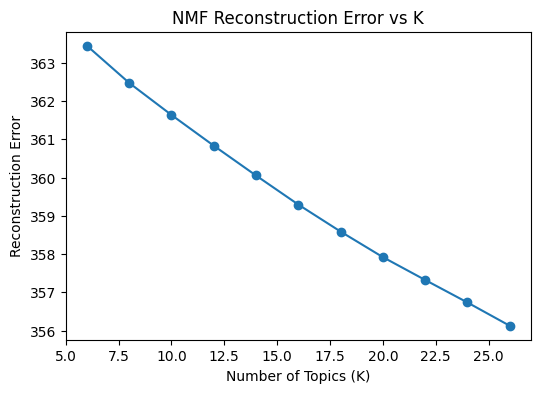

In [10]:
# Plot error
plt.figure(figsize=(6,4))
plt.plot(K_values, errors, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Reconstruction Error")
plt.title("NMF Reconstruction Error vs K")
plt.show()

On this plot there isn’t a sharp “elbow” given the reconstruction error drops almost linearly as K increases. There is a slight elbow at around 16 where it flattens out a bit.

In [11]:
# Create topic table for best k
def nmf_topic_table(nmf_model, vectorizer, top_n=15):
    feature_names = np.array(vectorizer.get_feature_names_out())
    rows = []
    for topic_idx, topic_weights in enumerate(nmf_model.components_):
        top_ids = topic_weights.argsort()[::-1][:top_n]
        top_terms = feature_names[top_ids]
        top_scores = topic_weights[top_ids]
        rows.append({
            "topic": topic_idx,
            "top_terms": ", ".join(top_terms),
            "top_term_scores": ", ".join([f"{s:.4f}" for s in top_scores])
        })
    return pd.DataFrame(rows)

best = models[16]
nmf_model = best["model"]
W = best["W"]

topic_info_nmf = nmf_topic_table(nmf_model, tfidf_title, top_n=15)
topic_info_nmf.head(16)

,topic,top_terms,top_term_scores
0,0,"intelligence, artificial, artificial intellige...","3.5159, 3.4948, 3.4834, 0.5154, 0.2551, 0.1700..."
1,1,"salary, data scientist, scientist, scientist s...","2.0412, 1.9863, 1.9701, 1.9445, 1.8507, 1.8506..."
2,2,"new, new ai, launches, technology, tool, model...","6.0696, 3.1555, 0.9746, 0.9188, 0.7210, 0.6854..."
3,3,"generative, generative ai, launches, market, p...","3.8235, 3.7828, 0.2675, 0.2427, 0.2307, 0.2023..."
4,4,"learning, machine, machine learning, ai machin...","2.4991, 2.4228, 2.3912, 0.3224, 0.2392, 0.2152..."
5,5,"openai, altman, sam, sam altman, ceo, microsof...","3.4546, 1.6292, 1.5431, 1.5355, 1.0297, 0.6857..."
6,6,"chatgpt, use, use chatgpt, using, like, users,...","3.8858, 0.5175, 0.3101, 0.2748, 0.2369, 0.2340..."
7,7,"news, tech, standard, tech news, news standard...","3.5364, 1.0790, 0.6165, 0.6158, 0.5729, 0.5175..."
8,8,"nasdaq, stock, stocks, nvidia, buy, ai stock, ...","2.5298, 1.7413, 1.2151, 1.0930, 1.0208, 0.9665..."
9,9,"google, gemini, google ai, bard, chatbot, gemi...","3.7421, 0.9767, 0.9108, 0.8042, 0.5367, 0.4911..."


In [12]:
# Save as parquet
save_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/nmf_topic_info_title.parquet"
topic_info_nmf.to_parquet(
    save_path,
    engine="pyarrow",
    compression="snappy"
)
print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/nmf_topic_info_title.parquet


In [13]:
# Dominant topic per document
df["nmf_topic_title"] = W.argmax(axis=1)
# Strength of that topic
df["nmf_topic_score_title"] = W.max(axis=1)

In [14]:
# Add key words to df
topic_lookup = dict(zip(topic_info_nmf["topic"], topic_info_nmf["top_terms"]))
df["nmf_topic_words_title"] = df["nmf_topic_title"].map(topic_lookup)
df[["title", "nmf_topic_title", "nmf_topic_score_title", "nmf_topic_words_title"]].head()

,title,nmf_topic_title,nmf_topic_score_title,nmf_topic_words_title
0,bad idea ai price bad market cap price today c...,14,0.051832,"price, mexc, price prediction, prediction, for..."
1,this ai video of gymnastics might be the freak...,12,0.002563,"art, ai art, bahamas, videos, photos, photos v..."
2,if using ai feels like chore try this boing boing,6,0.008090,"chatgpt, use, use chatgpt, using, like, users,..."
3,the road ahead how china ai foundation model i...,7,0.007651,"news, tech, standard, tech news, news standard..."
4,microsoft and nvidia to empower developers wit...,8,0.014000,"nasdaq, stock, stocks, nvidia, buy, ai stock, ..."


In [15]:
# Save as parquet
save_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/nmf_title.parquet"
df.to_parquet(save_path, engine="pyarrow", index=False)
print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/nmf_title.parquet
